                THIS PROJECT IS TO PREDICT IF A CUSTOMER IS WORTHY TO BE GIVEN A LOAN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/ALGORITHM/Documents/DATA SET/CreditScoring.csv")

In [3]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.Status.unique()

array([1, 2, 0], dtype=int64)

        Converting the columns to lower_case

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [7]:
df.records.unique()

array([1, 2], dtype=int64)

            Checking the statistical form of the data

In [8]:
df.describe().round()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,1.0,8.0,3.0,46.0,37.0,2.0,1.0,2.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,0.0,8.0,2.0,15.0,11.0,1.0,0.0,1.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,0.0,0.0,6.0,18.0,0.0,1.0,0.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,1.0,2.0,2.0,36.0,28.0,2.0,1.0,1.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,1.0,5.0,2.0,48.0,36.0,2.0,1.0,1.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,2.0,12.0,4.0,60.0,45.0,2.0,1.0,3.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,2.0,48.0,6.0,72.0,68.0,5.0,2.0,4.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [9]:
df.columns

Index(['status', 'seniority', 'home', 'time', 'age', 'marital', 'records',
       'job', 'expenses', 'income', 'assets', 'debt', 'amount', 'price'],
      dtype='object')

In [10]:
categorical = ['status', 'home', 'marital', 'records',
       'job']

                    DATA PRE_PROCESSING

In [11]:
df.status.unique()

array([1, 2, 0], dtype=int64)

In [12]:
df.status = df.status.map({1:"ok", 2:"default", 0:"unk"})

In [13]:
df.status.unique()

array(['ok', 'default', 'unk'], dtype=object)

In [14]:
df.status.value_counts()

status
ok         3200
default    1254
unk           1
Name: count, dtype: int64

            Home

In [15]:
df.home.unique()

array([1, 2, 5, 3, 6, 4, 0], dtype=int64)

In [16]:
df.home = df.home.map({1:"rent", 2:'owner', 5:'parent', 3:'private', 6:'other', 4:'ignore', 0:'unk'})

In [17]:
df.home.unique()

array(['rent', 'owner', 'parent', 'private', 'other', 'ignore', 'unk'],
      dtype=object)

                    Marital

In [18]:
df.marital.unique()

array([2, 3, 1, 4, 5, 0], dtype=int64)

In [19]:
df.marital = df.marital.map({2:'married', 3:'widow', 1:"single", 4:'separated', 5:'divorce', 0:'unk'})

                    Records

In [20]:
df.records.unique()

array([1, 2], dtype=int64)

In [21]:
df.records = df.records.map({1:'no', 2:'yes'})

In [22]:
df.records.unique()

array(['no', 'yes'], dtype=object)

            Jobs

In [23]:
df.job.unique()

array([3, 1, 2, 0, 4], dtype=int64)

In [24]:
df.job = df.job.map({3:'freelance', 1:'fixed', 2:'partime', 0:'unk', 4:'other'})

In [25]:
df.job.unique()

array(['freelance', 'fixed', 'partime', 'unk', 'other'], dtype=object)

In [26]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,default,1,rent,60,39,married,no,fixed,69,92,0,0,900,1020
4451,ok,22,owner,60,46,married,no,fixed,60,75,3000,600,950,1263
4452,default,0,owner,24,37,married,no,partime,60,90,3500,0,500,963
4453,ok,0,rent,48,23,single,no,freelance,49,140,0,0,550,550


In [27]:
df.status.unique()

array(['ok', 'default', 'unk'], dtype=object)

In [28]:
for c in categorical:
    print(c)
    print(df[c].unique())
    print()

status
['ok' 'default' 'unk']

home
['rent' 'owner' 'parent' 'private' 'other' 'ignore' 'unk']

marital
['married' 'widow' 'single' 'separated' 'divorce' 'unk']

records
['no' 'yes']

job
['freelance' 'fixed' 'partime' 'unk' 'other']



        Looking at the loop above, we have an unk = unknown in (status, home, marital and job ).
        We need to replace the unk to an unknown value =[ Nan ]

In [29]:
unknown = ["status", "home", "marital", "job"]

In [30]:
for i in unknown:
    df[i] = df[i].replace(to_replace = "unk", value = np.nan)

In [31]:
df.status.unique()

array(['ok', 'default', nan], dtype=object)

In [32]:
df.status = df.status.replace(to_replace = "unk", value = np.nan)

In [33]:
df.isna().sum()

status       1
seniority    0
home         6
time         0
age          0
marital      1
records      0
job          2
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

NB: we have missing variables in (status, home, marital, job)

In [34]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [35]:
missing = ["income","assets", "debt" ]

In [36]:
df[missing].max()

income    99999999
assets    99999999
debt      99999999
dtype: int64

In [37]:
for m in missing:
    df[m] = df[m].replace(to_replace = 99999999, value = np.nan)

In [38]:
df.income.max()

959.0

In [39]:
df.isna().sum()

status        1
seniority     0
home          6
time          0
age           0
marital       1
records       0
job           2
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

NB: we have missing values in status, home, marital, job, income, assets, debt

To solve for missing values, we are filling the nan to the mean of their unique values for numerical varibles while for categorical variables we will fill it to the mode of their unique values

In [40]:
df= df.fillna(df.mean(numeric_only = True))

In [41]:
df.isna().sum()

status       1
seniority    0
home         6
time         0
age          0
marital      1
records      0
job          2
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

In [42]:
df = df.fillna(df.mode().iloc[0])

In [43]:
df.isna().sum()

status       0
seniority    0
home         0
time         0
age          0
marital      0
records      0
job          0
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

We have solve the case of missing

                        DATA ANALYSIS

In [44]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4451,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4452,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4453,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [45]:
df.shape

(4455, 14)

In [46]:
df.status.unique()

array(['ok', 'default'], dtype=object)

In [47]:
df.status = (df.status == "default").astype("int")

In [48]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,0,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,1,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,0,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,0,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,1,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4451,0,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4452,1,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4453,0,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [49]:
df.home.unique()

array(['rent', 'owner', 'parent', 'private', 'other', 'ignore'],
      dtype=object)

In [50]:
df.status.mean()

0.2814814814814815

There are lot of ways to check the effect 
1. comparing each variables(unique) to the mean of status: Any varibles that is greater than the mean has chances of not paying back(runaway)
2. Visualizing it

In [51]:
df.loc[df.home == "rent"].status.mean()

0.3987667009249743

In [52]:
df.loc[df.home == "owner"].status.mean()

0.18646474207288216

In [53]:
df.groupby("home").status.agg(["mean", "count"])

,mean,count
home,,
ignore,0.450000,20
other,0.457680,319
owner,0.186465,2113
parent,0.297573,783
private,0.340081,247
rent,0.398767,973


In [54]:
df.status.mean()

0.2814814814814815

We can deduce that (ignore and other has a very high chances of not paying back i.e running away); rent,  and private also has chances of not paying but owner and parent are likely to pay back

<Axes: xlabel='home', ylabel='status'>

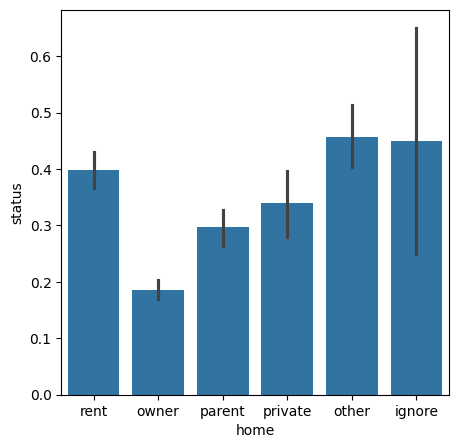

In [55]:
plot = plt.figure(figsize = (5,5))
sns.barplot(x = "home", y = "status", data = df)

from the above plot, if the mean is 0.3(approx), it shows that (owner and parent are qualified )  but the rest are above 0.3 

In [56]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,0,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,1,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,0,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,0,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


                MARITAL
                

In [57]:
df.marital.unique()

array(['married', 'widow', 'single', 'separated', 'divorce'], dtype=object)

In [58]:
df.loc[(df.marital == "married")].status.mean()

0.25570635410240594

Recall the status is 0.29, so the married are less likely not to pay back

In [59]:
df.groupby("marital").status.agg(["mean","count"])

,mean,count
marital,,
divorce,0.368421,38
married,0.255706,3242
separated,0.492308,130
single,0.335378,978
widow,0.283582,67


seperated, divorce  and single are likely not to pay back

<Axes: xlabel='marital', ylabel='status'>

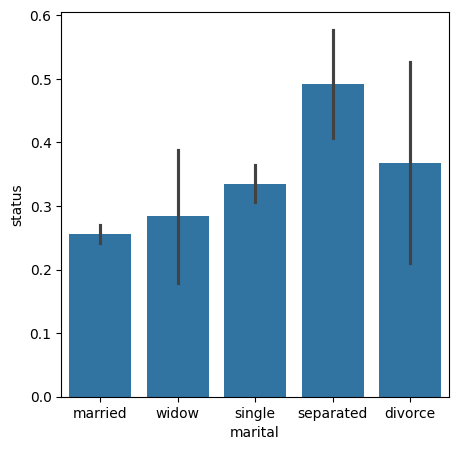

In [60]:
plot = plt.figure(figsize = (5,5))
sns.barplot(x = "marital", y = "status", data = df)

If i am the bank, I wont even bother giving the separated at all because they dont have hope at all.
NB: lets say the mean is 0.3

                    JOB

In [61]:
df.groupby("job").status.agg(["count","mean"])

,count,mean
job,,
fixed,2808,0.207265
freelance,1024,0.325195
other,171,0.397661
partime,452,0.599558


partime no get joy at all but with a fixed job you are likely to pay backk

                RECORDS

In [62]:
df.records.unique()

array(['no', 'yes'], dtype=object)

<Axes: xlabel='records', ylabel='status'>

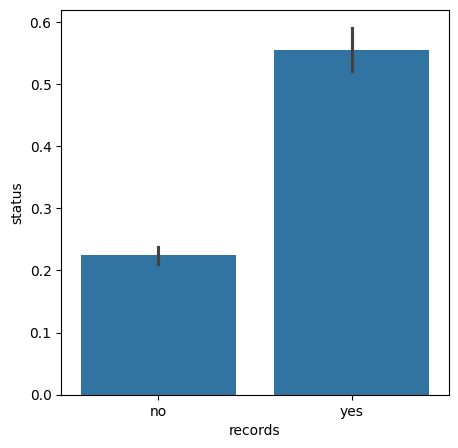

In [63]:
plot = plt.figure(figsize =(5,5))
sns.barplot(x= "records", y = "status", data = df)

Obviously

                        To Check for the relationship between the numerical values

In [64]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,0,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,1,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,0,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,0,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


In [65]:
df[["seniority", "expenses", "income", "assets", "debt", "amount", "price"]].corrwith(df.status)

seniority   -0.260414
expenses     0.028999
income      -0.208057
assets      -0.096350
debt         0.011143
amount       0.154390
price        0.010644
dtype: float64

            SPLITTING THE DATA INTO TRAIN, VALIDATION AND TEST

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
df_full, df_test = train_test_split(df, test_size = 0.2, random_state = 1)
df_train, df_val = train_test_split(df_full, test_size = 0.2, random_state = 1)

In [68]:
df_full = df_full.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_train = df_train.reset_index(drop = True)

            getting ur target variable

In [69]:
y_full = df_full["status"]
y_test = df_test["status"]
y_train = df_train["status"]
y_val = df_val["status"]

             Removing the target varible from the each data

In [70]:
del df_full["status"]
del df_test["status"]
del df_val["status"]
del df_train["status"]

                Encoding the data for the model to understand

In [71]:
from sklearn.feature_extraction import DictVectorizer

In [72]:
dv = DictVectorizer(sparse = False)

       To encode it, you convert the dataframe to dictionary

In [73]:
full_dict = df_full.to_dict(orient= "records")
train_dict = df_train.to_dict(orient= "records")
test_dict = df_test.to_dict(orient= "records")
val_dict = df_val.to_dict(orient= "records")

                        Encoding the dataset

For now, we are dealing with the train and val dataset
we try each algorithms on the train dataset, test it and evalulate the perfomance on the validation dataset.
Then we use the model with the highest accuracy on the full dataset and test it on the test dataset

In [74]:
dv.fit(train_dict)

DictVectorizer(sparse=False)

In [75]:
train = dv.transform(train_dict)

In [76]:
val = dv.transform(val_dict)

            Training with Logistic Regression because obviously we cant use linear(the output is not a linear number i.e a continuous number but binary)

In [77]:
from sklearn.linear_model import LogisticRegression

In [78]:
lr = LogisticRegression()

In [79]:
lr.fit(train,y_train)

C:\Users\ALGORITHM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [80]:
lr_pred = lr.predict(val)

                    Evaluating the performance of the logistic model

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score

                ACCURACY

In [82]:
accuracy_score(y_val, lr_pred) 

0.761570827489481

It shows that our accuracy is 76% which is not bad.

                Confusion_matrix

In [83]:
confusion_matrix(y_val, lr_pred)

array([[477,  33],
       [137,  66]], dtype=int64)

In [84]:
precision_score(y_val, lr_pred)

0.6666666666666666

for precision, out of 99 positve prediction we got 66 correctly

In [85]:
recall_score(y_val, lr_pred)

0.3251231527093596

our model is kinda not looking good, it means out of 203(ones) of actual value we got 66 correct, which is bad

            TRAINING WITH K_NEAREST_NEIGHBOUR

In [86]:
from sklearn.neighbors import KNeighborsClassifier

In [87]:
import math

In [88]:
len(train)

2851

In [89]:
math.sqrt(len(train))

53.39475629684998

In [90]:
knn = KNeighborsClassifier(n_neighbors = 51, metric = "euclidean")

In [91]:
knn.fit(train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=51)

In [92]:
k_pred = knn.predict(val)

In [93]:
from sklearn.metrics import r2_score

In [94]:
accuracy_score(y_val, k_pred)

0.7363253856942497

In [95]:
confusion_matrix(y_val, k_pred)

array([[487,  23],
       [165,  38]], dtype=int64)

In [96]:
recall_score(y_val, k_pred)

0.18719211822660098

In [97]:
precision_score(y_val, k_pred)

0.6229508196721312

                            TRAINING WITH DECISION_TREE

In [98]:
from sklearn.tree import DecisionTreeClassifier

In [99]:
tree = DecisionTreeClassifier(max_depth = 5)

In [100]:
tree.fit(train, y_train)

DecisionTreeClassifier(max_depth=5)

In [101]:
tr_pred = tree.predict(val)

In [102]:
accuracy_score(y_val, tr_pred)

0.7784011220196353

In [103]:
precision_score(y_val, tr_pred)

0.6415094339622641

In [104]:
recall_score(y_val, tr_pred)

0.5024630541871922

In [105]:
confusion_matrix(y_val, tr_pred)

array([[453,  57],
       [101, 102]], dtype=int64)

                            RANDOM FOREST

In [106]:
from sklearn.ensemble import RandomForestClassifier

In [107]:
rd = RandomForestClassifier(max_depth = 10)

In [108]:
rd.fit(train, y_train)

RandomForestClassifier(max_depth=10)

In [109]:
r_pred = rd.predict(val)

In [110]:
accuracy_score(y_val, r_pred)

0.782608695652174

In [111]:
confusion_matrix(y_val, r_pred)

array([[468,  42],
       [113,  90]], dtype=int64)

In [112]:
recall_score(y_val, r_pred)

0.4433497536945813

In [113]:
precision_score(y_val, r_pred)

0.6818181818181818

                FROM THE ABOVE TRAINING, RANDOM FOREST HAS THE HIGHEST ACCURACY

WE WILL TAKE THE FULL DATASET AND TRAIN IT THEN TEST IT WITH THE TEST DATASET

In [114]:
dv = DictVectorizer(sparse = True)

In [115]:
dv.fit(full_dict)

DictVectorizer()

In [116]:
full = dv.transform(full_dict)
test = dv.transform(test_dict)

In [117]:
model = RandomForestClassifier(max_depth = 50)

In [118]:
model.fit(full , y_full)

RandomForestClassifier(max_depth=50)

In [119]:
pred = model.predict(test)

In [120]:
accuracy_score(y_test, pred)

0.7777777777777778